<a href="https://colab.research.google.com/github/iiiyahiya111/Project/blob/main/Week_4_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

WEEK 4 — FiLM + JS DISAGREEMENT + CONFLICT-AWARE GATE
Device: cuda
AMP: True
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Google Drive mounted.

Environment ZIP:
/content/drive/MyDrive/Dataset_1_Image_Environment.zip

Severity ZIP:
/content/drive/MyDrive/Potato_Severity_Dataset_DEDUPED_FINAL.zip

Extracting:
/content/drive/MyDrive/Dataset_1_Image_Environment.zip

Extracting:
/content/drive/MyDrive/Potato_Severity_Dataset_DEDUPED_FINAL.zip

Located files:
Image-level : /content/week4_research/datasets/environment/synthetic_environment_image_level.csv
Daily       : /content/week4_research/datasets/environment/synthetic_environment_daily_v2.csv
Hourly      : /content/week4_research/datasets/environment/synthetic_environment_hourly.csv
Severity    : /content/week4_research/datasets/severity/Potato_Severity_Dataset_FINAL/severity_dataset/potato_severity_FINAL.csv

Dataset shapes:
Environment image-level: (1

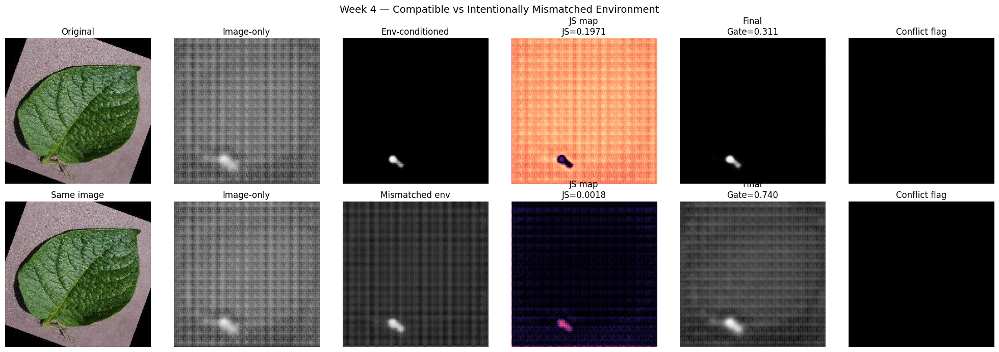


Visualization saved: /content/week4_research/outputs/week4_compatible_vs_mismatched_visualization.png
Compatible filename: 101_Potato_Healthy_train_JPG.rf.140adb40478e116530cc9718b90080a1.jpg
Mismatched environment donor: 197_Potato_Late_Blight_train_JPG.rf.3fe7583ff6a7720bbb4d41a64bd590e5.jpg

WEEK 4 COMPLETE

Best weights: /content/week4_research/outputs/week4_best_state_dict.pt
Best config: /content/week4_research/outputs/week4_best_config.json
Training history: /content/week4_research/outputs/week4_training_history.csv
Mismatch pairs: /content/week4_research/outputs/week4_mismatch_pairs.csv
Visualization: /content/week4_research/outputs/week4_compatible_vs_mismatched_visualization.png

Done.


In [4]:
# =====================================================================
# WEEK 4 RESEARCH VERSION
# FiLM + JS Disagreement + Conflict-Aware Learned Gate
#
# COMPLETE SINGLE-CELL GOOGLE COLAB IMPLEMENTATION
# =====================================================================

# ---------------------------------------------------------------------
# 0. Imports / configuration
# ---------------------------------------------------------------------
import os
import glob
import json
import zipfile
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2

from google.colab import drive

warnings.filterwarnings("ignore")

# -------------------------
# Reproducibility
# -------------------------
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# -------------------------
# Device / AMP
# -------------------------
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

AMP = DEVICE.type == "cuda"

print("=" * 78)
print("WEEK 4 — FiLM + JS DISAGREEMENT + CONFLICT-AWARE GATE")
print("=" * 78)
print("Device:", DEVICE)
print("AMP:", AMP)


# ---------------------------------------------------------------------
# 1. Mount Google Drive
# ---------------------------------------------------------------------
drive.mount("/content/drive")

print("\nGoogle Drive mounted.")


# ---------------------------------------------------------------------
# 2. Automatically locate ZIP files
# ---------------------------------------------------------------------
ENV_NAME = "Dataset_1_Image_Environment.zip"
SEV_NAME = "Potato_Severity_Dataset_DEDUPED_FINAL.zip"

SEARCH_ROOTS = [
    "/content",
    "/content/drive/MyDrive"
]

def find_file(filename):
    matches = []

    for root in SEARCH_ROOTS:
        matches.extend(
            glob.glob(
                os.path.join(
                    root,
                    "**",
                    filename
                ),
                recursive=True
            )
        )

    # Remove duplicates while preserving order
    matches = list(dict.fromkeys(matches))

    return matches[0] if matches else None


ENV_ZIP = find_file(ENV_NAME)
SEV_ZIP = find_file(SEV_NAME)

if ENV_ZIP is None or SEV_ZIP is None:

    from google.colab import files

    print("\nZIP file(s) not found automatically.")
    print("Upload the missing ZIP file(s).")

    uploaded = files.upload()

    if ENV_ZIP is None and ENV_NAME in uploaded:
        ENV_ZIP = "/content/" + ENV_NAME

    if SEV_ZIP is None and SEV_NAME in uploaded:
        SEV_ZIP = "/content/" + SEV_NAME


if ENV_ZIP is None:
    raise FileNotFoundError(
        f"Could not locate {ENV_NAME}"
    )

if SEV_ZIP is None:
    raise FileNotFoundError(
        f"Could not locate {SEV_NAME}"
    )

print("\nEnvironment ZIP:")
print(ENV_ZIP)

print("\nSeverity ZIP:")
print(SEV_ZIP)


# ---------------------------------------------------------------------
# 3. Extract datasets
# ---------------------------------------------------------------------
ROOT_DIR = "/content/week4_research"

DATA_DIR = os.path.join(
    ROOT_DIR,
    "datasets"
)

ENV_DIR = os.path.join(
    DATA_DIR,
    "environment"
)

SEV_DIR = os.path.join(
    DATA_DIR,
    "severity"
)

OUTPUT_DIR = os.path.join(
    ROOT_DIR,
    "outputs"
)

os.makedirs(
    ENV_DIR,
    exist_ok=True
)

os.makedirs(
    SEV_DIR,
    exist_ok=True
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)


def extract_once(zip_path, output_dir):

    marker = os.path.join(
        output_dir,
        ".done"
    )

    if not os.path.exists(marker):

        print("\nExtracting:")
        print(zip_path)

        with zipfile.ZipFile(
            zip_path,
            "r"
        ) as z:

            z.extractall(
                output_dir
            )

        Path(marker).touch()

    else:

        print(
            "\nAlready extracted:",
            output_dir
        )


extract_once(
    ENV_ZIP,
    ENV_DIR
)

extract_once(
    SEV_ZIP,
    SEV_DIR
)


# ---------------------------------------------------------------------
# 4. Locate required CSV files
# ---------------------------------------------------------------------
def find_exact(root, filename):

    matches = glob.glob(
        os.path.join(
            root,
            "**",
            filename
        ),
        recursive=True
    )

    if not matches:
        raise FileNotFoundError(
            f"{filename} not found inside {root}"
        )

    return matches[0]


ENV_IMAGE_CSV = find_exact(
    ENV_DIR,
    "synthetic_environment_image_level.csv"
)

ENV_DAILY_CSV = find_exact(
    ENV_DIR,
    "synthetic_environment_daily_v2.csv"
)

ENV_HOURLY_CSV = find_exact(
    ENV_DIR,
    "synthetic_environment_hourly.csv"
)

SEVERITY_CSV = find_exact(
    SEV_DIR,
    "potato_severity_FINAL.csv"
)

print("\nLocated files:")
print("Image-level :", ENV_IMAGE_CSV)
print("Daily       :", ENV_DAILY_CSV)
print("Hourly      :", ENV_HOURLY_CSV)
print("Severity    :", SEVERITY_CSV)


# ---------------------------------------------------------------------
# 5. Load CSVs
# ---------------------------------------------------------------------
env_image = pd.read_csv(
    ENV_IMAGE_CSV
)

env_daily = pd.read_csv(
    ENV_DAILY_CSV
)

env_hourly = pd.read_csv(
    ENV_HOURLY_CSV
)

severity = pd.read_csv(
    SEVERITY_CSV
)

print("\nDataset shapes:")
print(
    "Environment image-level:",
    env_image.shape
)

print(
    "Environment daily:",
    env_daily.shape
)

print(
    "Environment hourly:",
    env_hourly.shape
)

print(
    "Severity:",
    severity.shape
)


# ---------------------------------------------------------------------
# 6. Keep valid severity records
# ---------------------------------------------------------------------
if "final_decision" in severity.columns:

    severity = severity[
        severity[
            "final_decision"
        ].astype(str).str.upper()
        == "KEEP"
    ].copy()

severity["filename"] = (
    severity["filename"]
    .astype(str)
)

print(
    "\nKept severity samples:",
    len(severity)
)

print(
    severity["split"].value_counts()
)


# ---------------------------------------------------------------------
# 7. Candidate-0 compatible environment
#
# 11530 image-level records correspond to:
#   1153 images × 10 candidates
#
# Candidate 0 is retained as the compatible environment.
#
# All 10 candidates remain available in the environment table,
# but the Week 4 base pairing uses candidate 0 consistently.
# ---------------------------------------------------------------------
env_image_candidate0 = env_image[
    env_image[
        "candidate_id"
    ] == 0
].copy()

env_image_candidate0[
    "filename"
] = env_image_candidate0[
    "filename"
].astype(str)

print(
    "\nCandidate-0 environment records:",
    len(env_image_candidate0)
)


# ---------------------------------------------------------------------
# 8. Construct 144-hour environment sequences
# ---------------------------------------------------------------------
ENV_FEATURES = [
    "temperature",
    "rh",
    "rainfall_hourly_proxy",
    "leaf_wetness_hourly_proxy",
    "soil_moisture",
    "rh_ge90"
]


# -------------------------
# Daily table
# -------------------------
daily = env_daily[
    [
        "filename",
        "image_id",
        "split",
        "class_name",
        "candidate_id",
        "day",
        "rainfall_mm",
        "leaf_wetness_hours",
        "soil_moisture"
    ]
].copy()

daily[
    "rainfall_hourly_proxy"
] = (
    daily["rainfall_mm"] / 24.0
)

daily[
    "leaf_wetness_hourly_proxy"
] = (
    daily["leaf_wetness_hours"] / 24.0
)


# -------------------------
# Hourly table
# -------------------------
hourly = env_hourly[
    [
        "filename",
        "image_id",
        "split",
        "class_name",
        "candidate_id",
        "hour",
        "day",
        "temperature",
        "rh",
        "rh_ge90"
    ]
].copy()


# -------------------------
# Merge daily -> hourly
# -------------------------
hourly = hourly.merge(
    daily[
        [
            "filename",
            "image_id",
            "split",
            "class_name",
            "candidate_id",
            "day",
            "rainfall_hourly_proxy",
            "leaf_wetness_hourly_proxy",
            "soil_moisture"
        ]
    ],
    on=[
        "filename",
        "image_id",
        "split",
        "class_name",
        "candidate_id",
        "day"
    ],
    how="left"
)


# -------------------------
# First 144 hours
# -------------------------
hourly = hourly[
    hourly["hour"] < 144
].copy()


env_sequences_raw = {}

for key, group in hourly.groupby(
    [
        "filename",
        "candidate_id"
    ]
):

    group = group.sort_values(
        "hour"
    )

    if len(group) < 144:
        continue

    seq = group.iloc[
        :144
    ][ENV_FEATURES].values.astype(
        np.float32
    )

    seq = np.nan_to_num(
        seq,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )

    env_sequences_raw[
        key
    ] = seq


print(
    "\nConstructed 144-hour sequences:",
    len(env_sequences_raw)
)


# ---------------------------------------------------------------------
# 9. Build matched severity records
# ---------------------------------------------------------------------
records = []

for _, row in severity.iterrows():

    filename = row["filename"]

    env_key = (
        filename,
        0
    )

    if env_key not in env_sequences_raw:
        continue

    records.append(
        {
            "filename":
                filename,

            "split":
                str(row["split"]),

            "class_name":
                str(row["class_name"]),

            "severity_percent":
                float(
                    row["severity_percent"]
                ),

            "image_path_original":
                str(row["image_path"]),

            "mask_path_original":
                str(
                    row["lesion_mask_path"]
                ),

            "env_key":
                env_key
        }
    )


dataset_df = pd.DataFrame(
    records
)

print(
    "\nMatched samples:",
    len(dataset_df)
)

print(
    dataset_df["split"].value_counts()
)


# ---------------------------------------------------------------------
# 10. Resolve actual image/mask files
# ---------------------------------------------------------------------
ALL_IMAGE_FILES = {}

for root, dirs, files_ in os.walk(
    SEV_DIR
):

    for file in files_:

        if file.lower().endswith(
            (
                ".jpg",
                ".jpeg",
                ".png"
            )
        ):

            ALL_IMAGE_FILES[
                file
            ] = os.path.join(
                root,
                file
            )


def resolve_file(path_text):

    base = os.path.basename(
        str(path_text)
    )

    return ALL_IMAGE_FILES.get(
        base,
        None
    )


dataset_df[
    "image_path"
] = dataset_df[
    "image_path_original"
].apply(
    resolve_file
)

dataset_df[
    "mask_path"
] = dataset_df[
    "mask_path_original"
].apply(
    resolve_file
)

dataset_df = dataset_df.dropna(
    subset=[
        "image_path",
        "mask_path"
    ]
).reset_index(
    drop=True
)

print(
    "\nSamples with actual image/mask:",
    len(dataset_df)
)


# ---------------------------------------------------------------------
# 11. Train / valid / test
# ---------------------------------------------------------------------
train_df = dataset_df[
    dataset_df["split"] == "train"
].reset_index(drop=True)

valid_df = dataset_df[
    dataset_df["split"] == "valid"
].reset_index(drop=True)

test_df = dataset_df[
    dataset_df["split"] == "test"
].reset_index(drop=True)

print("\nFinal splits:")
print("Train:", len(train_df))
print("Valid:", len(valid_df))
print("Test :", len(test_df))


# ---------------------------------------------------------------------
# 12. Train-only environment normalization
#
# IMPORTANT:
# normalization statistics use only compatible train environments.
# No validation/test statistics enter normalization.
# ---------------------------------------------------------------------
train_env_arrays = []

for key in train_df[
    "env_key"
].tolist():

    train_env_arrays.append(
        env_sequences_raw[
            key
        ]
    )

train_env_concat = np.concatenate(
    train_env_arrays,
    axis=0
)

env_mean = np.mean(
    train_env_concat,
    axis=0
)

env_std = np.std(
    train_env_concat,
    axis=0
)

env_std[
    env_std < 1e-6
] = 1.0


env_sequences = {}

for key, seq in env_sequences_raw.items():

    seq = (
        seq - env_mean
    ) / env_std

    env_sequences[
        key
    ] = seq.astype(
        np.float32
    )


print(
    "\nEnvironment normalization fitted on TRAIN only."
)


# ---------------------------------------------------------------------
# 13. Build hard-negative mismatched environments
#
# Rules:
#   - same train/valid/test split
#   - donor filename != base filename
#   - prefer a different class when available
#   - choose an environment summary that is far away in
#     normalized environment space
#
# This avoids cross-split leakage.
# ---------------------------------------------------------------------
def environment_summary(key):

    seq = env_sequences[
        key
    ]

    # Temporal mean + temporal variability
    mean_part = np.mean(
        seq,
        axis=0
    )

    std_part = np.std(
        seq,
        axis=0
    )

    return np.concatenate(
        [
            mean_part,
            std_part
        ],
        axis=0
    )


summary_cache = {}

for key in env_sequences:

    if key[1] == 0:

        summary_cache[
            key
        ] = environment_summary(
            key
        )


def build_mismatch_map(df):

    rows = df.reset_index(
        drop=True
    ).copy()

    filenames = rows[
        "filename"
    ].tolist()

    classes = rows[
        "class_name"
    ].tolist()

    summaries = np.stack(
        [
            summary_cache[
                (f, 0)
            ]
            for f in filenames
        ]
    )

    mismatch = {}

    for i, filename in enumerate(
        filenames
    ):

        # Same split only because df was already split-specific.
        candidates = [
            j
            for j in range(
                len(filenames)
            )
            if filenames[j] != filename
        ]

        if not candidates:
            raise RuntimeError(
                "No mismatch candidate available."
            )

        # Prefer a different class.
        different_class = [
            j
            for j in candidates
            if classes[j] != classes[i]
        ]

        if len(
            different_class
        ) >= 1:

            pool = different_class

        else:

            pool = candidates

        target = summaries[i]

        pool_vectors = summaries[
            pool
        ]

        dists = np.mean(
            (
                pool_vectors
                - target[None, :]
            ) ** 2,
            axis=1
        )

        best_local = int(
            np.argmax(dists)
        )

        donor_idx = pool[
            best_local
        ]

        donor_filename = filenames[
            donor_idx
        ]

        mismatch[
            filename
        ] = (
            donor_filename,
            float(
                dists[best_local]
            )
        )

    return mismatch


train_mismatch = build_mismatch_map(
    train_df
)

valid_mismatch = build_mismatch_map(
    valid_df
)

test_mismatch = build_mismatch_map(
    test_df
)


def attach_mismatch(df, mismatch_map):

    df = df.copy()

    df["mismatch_filename"] = df[
        "filename"
    ].map(
        lambda x:
        mismatch_map[x][0]
    )

    df["mismatch_key"] = df[
        "mismatch_filename"
    ].map(
        lambda x:
        (x, 0)
    )

    df["mismatch_distance"] = df[
        "filename"
    ].map(
        lambda x:
        mismatch_map[x][1]
    )

    return df


train_df = attach_mismatch(
    train_df,
    train_mismatch
)

valid_df = attach_mismatch(
    valid_df,
    valid_mismatch
)

test_df = attach_mismatch(
    test_df,
    test_mismatch
)


# Save pair mapping for reproducibility.
pair_table = pd.concat(
    [
        train_df[
            [
                "filename",
                "split",
                "mismatch_filename",
                "mismatch_distance"
            ]
        ],
        valid_df[
            [
                "filename",
                "split",
                "mismatch_filename",
                "mismatch_distance"
            ]
        ],
        test_df[
            [
                "filename",
                "split",
                "mismatch_filename",
                "mismatch_distance"
            ]
        ]
    ],
    ignore_index=True
)

pair_table.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "week4_mismatch_pairs.csv"
    ),
    index=False
)


print(
    "\nMismatch maps created:"
)

print(
    "Train:",
    len(train_df)
)

print(
    "Valid:",
    len(valid_df)
)

print(
    "Test :",
    len(test_df)
)


# ---------------------------------------------------------------------
# 14. Dataset transforms
# ---------------------------------------------------------------------
IMG_SIZE = 256

train_transform = A.Compose(
    [
        A.Resize(
            IMG_SIZE,
            IMG_SIZE
        ),

        A.HorizontalFlip(
            p=0.5
        ),

        A.VerticalFlip(
            p=0.2
        ),

        A.RandomRotate90(
            p=0.2
        ),

        A.Normalize(
            mean=(
                0.485,
                0.456,
                0.406
            ),
            std=(
                0.229,
                0.224,
                0.225
            )
        ),

        ToTensorV2()
    ]
)


valid_transform = A.Compose(
    [
        A.Resize(
            IMG_SIZE,
            IMG_SIZE
        ),

        A.Normalize(
            mean=(
                0.485,
                0.456,
                0.406
            ),
            std=(
                0.229,
                0.224,
                0.225
            )
        ),

        ToTensorV2()
    ]
)


# ---------------------------------------------------------------------
# 15. Dataset
# ---------------------------------------------------------------------
class Week4Dataset(Dataset):

    def __init__(
        self,
        dataframe,
        transform
    ):

        self.df = dataframe.reset_index(
            drop=True
        )

        self.transform = transform

    def __len__(self):
        return len(
            self.df
        )

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        image = np.array(
            Image.open(
                row["image_path"]
            ).convert("RGB")
        )

        mask = np.array(
            Image.open(
                row["mask_path"]
            ).convert("L")
        )

        mask = (
            mask > 0
        ).astype(
            np.float32
        )

        if self.transform is not None:

            transformed = self.transform(
                image=image,
                mask=mask
            )

            image = transformed[
                "image"
            ]

            mask = transformed[
                "mask"
            ]

        if mask.ndim == 2:

            mask = mask.unsqueeze(0)

        env_compatible = torch.tensor(
            env_sequences[
                row["env_key"]
            ],
            dtype=torch.float32
        )

        env_mismatch = torch.tensor(
            env_sequences[
                row["mismatch_key"]
            ],
            dtype=torch.float32
        )

        return {
            "image":
                image,

            "mask":
                mask.float(),

            "environment_compatible":
                env_compatible,

            "environment_mismatch":
                env_mismatch,

            "filename":
                row["filename"],

            "mismatch_filename":
                row["mismatch_filename"],

            "severity":
                torch.tensor(
                    row["severity_percent"],
                    dtype=torch.float32
                )
        }


# ---------------------------------------------------------------------
# 16. DataLoaders
# ---------------------------------------------------------------------
BATCH_SIZE = 8

train_ds = Week4Dataset(
    train_df,
    train_transform
)

valid_ds = Week4Dataset(
    valid_df,
    valid_transform
)

test_ds = Week4Dataset(
    test_df,
    valid_transform
)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

valid_loader = DataLoader(
    valid_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("\nDataloaders ready.")


# ---------------------------------------------------------------------
# 17. Model components
# ---------------------------------------------------------------------
class ConvBlock(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels
    ):

        super().__init__()

        self.block = nn.Sequential(

            nn.Conv2d(
                in_channels,
                out_channels,
                3,
                padding=1,
                bias=False
            ),

            nn.BatchNorm2d(
                out_channels
            ),

            nn.ReLU(
                inplace=True
            ),

            nn.Conv2d(
                out_channels,
                out_channels,
                3,
                padding=1,
                bias=False
            ),

            nn.BatchNorm2d(
                out_channels
            ),

            nn.ReLU(
                inplace=True
            )
        )

    def forward(self, x):
        return self.block(x)


class ImageEncoder(nn.Module):

    def __init__(self):

        super().__init__()

        self.b1 = ConvBlock(
            3,
            32
        )

        self.b2 = ConvBlock(
            32,
            64
        )

        self.b3 = ConvBlock(
            64,
            128
        )

        self.b4 = ConvBlock(
            128,
            256
        )

        self.pool = nn.MaxPool2d(
            2
        )

    def forward(self, x):

        x = self.b1(x)
        x = self.pool(x)

        x = self.b2(x)
        x = self.pool(x)

        x = self.b3(x)
        x = self.pool(x)

        x = self.b4(x)
        x = self.pool(x)

        return x


class EnvironmentEncoder(nn.Module):

    def __init__(
        self,
        input_dim=6,
        hidden_dim=128
    ):

        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            batch_first=True,
            bidirectional=True
        )

        self.projection = nn.Sequential(

            nn.Linear(
                hidden_dim * 2,
                hidden_dim
            ),

            nn.ReLU(),

            nn.Dropout(
                0.1
            )
        )

    def forward(self, x):

        _, (h, _) = self.lstm(
            x
        )

        forward_h = h[-2]
        backward_h = h[-1]

        h = torch.cat(
            [
                forward_h,
                backward_h
            ],
            dim=1
        )

        return self.projection(
            h
        )


class FiLM(nn.Module):

    def __init__(
        self,
        env_dim,
        channels
    ):

        super().__init__()

        self.gamma = nn.Linear(
            env_dim,
            channels
        )

        self.beta = nn.Linear(
            env_dim,
            channels
        )

    def forward(
        self,
        x,
        env_embedding
    ):

        gamma = self.gamma(
            env_embedding
        ).unsqueeze(
            -1
        ).unsqueeze(
            -1
        )

        beta = self.beta(
            env_embedding
        ).unsqueeze(
            -1
        ).unsqueeze(
            -1
        )

        return (
            gamma * x + beta
        )


class DecoderBlock(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels
    ):

        super().__init__()

        self.up = nn.ConvTranspose2d(
            in_channels,
            out_channels,
            2,
            stride=2
        )

        self.conv = ConvBlock(
            out_channels,
            out_channels
        )

    def forward(self, x):

        x = self.up(x)

        x = self.conv(
            x
        )

        return x


# ---------------------------------------------------------------------
# 18. Research-valid Week 4 model
# ---------------------------------------------------------------------
class Week4Model(nn.Module):

    def __init__(
        self,
        env_dim=128
    ):

        super().__init__()

        # Image branch
        self.image_encoder = ImageEncoder()

        # Environment branch
        self.environment_encoder = EnvironmentEncoder(
            input_dim=6,
            hidden_dim=env_dim
        )

        # FiLM decoder
        self.dec4 = DecoderBlock(
            256,
            128
        )

        self.dec3 = DecoderBlock(
            128,
            64
        )

        self.dec2 = DecoderBlock(
            64,
            32
        )

        self.dec1 = DecoderBlock(
            32,
            16
        )

        self.film4 = FiLM(
            env_dim,
            128
        )

        self.film3 = FiLM(
            env_dim,
            64
        )

        self.film2 = FiLM(
            env_dim,
            32
        )

        self.film1 = FiLM(
            env_dim,
            16
        )

        # Independent prediction heads
        self.image_head = nn.Conv2d(
            16,
            1,
            1
        )

        self.environment_head = nn.Conv2d(
            16,
            1,
            1
        )

        # Fused prediction
        self.fused_head = nn.Sequential(

            nn.Conv2d(
                32,
                16,
                3,
                padding=1
            ),

            nn.ReLU(
                inplace=True
            ),

            nn.Conv2d(
                16,
                1,
                1
            )
        )

        # -------------------------------------------------------------
        # LEARNED GATE
        #
        # Inputs:
        #   1. JS disagreement
        #   2. image confidence
        #   3. environment confidence
        #
        # Direct conflict supervision:
        #   compatible = 0
        #   mismatch   = 1
        # -------------------------------------------------------------
        self.gate_mlp = nn.Sequential(

            nn.LayerNorm(3),

            nn.Linear(
                3,
                32
            ),

            nn.ReLU(),

            nn.Linear(
                32,
                16
            ),

            nn.ReLU(),

            nn.Linear(
                16,
                1
            )
        )

    def encode_image(
        self,
        image
    ):

        return self.image_encoder(
            image
        )

    def image_features(
        self,
        z
    ):

        x = self.dec4(z)
        x = self.dec3(x)
        x = self.dec2(x)
        x = self.dec1(x)

        return x

    def environment_features(
        self,
        z,
        env_embedding
    ):

        x = self.dec4(z)

        x = self.film4(
            x,
            env_embedding
        )

        x = self.dec3(x)

        x = self.film3(
            x,
            env_embedding
        )

        x = self.dec2(x)

        x = self.film2(
            x,
            env_embedding
        )

        x = self.dec1(x)

        x = self.film1(
            x,
            env_embedding
        )

        return x

    @staticmethod
    def js_divergence_binary(
        p,
        q
    ):

        # Explicit FP32 for numerical stability.
        p = p.float().clamp(
            1e-6,
            1.0 - 1e-6
        )

        q = q.float().clamp(
            1e-6,
            1.0 - 1e-6
        )

        m = 0.5 * (
            p + q
        )

        kl_pm = (
            p * (
                torch.log(p)
                - torch.log(m)
            )
            +
            (1.0 - p) * (
                torch.log(1.0 - p)
                -
                torch.log(1.0 - m)
            )
        )

        kl_qm = (
            q * (
                torch.log(q)
                - torch.log(m)
            )
            +
            (1.0 - q) * (
                torch.log(1.0 - q)
                -
                torch.log(1.0 - m)
            )
        )

        return 0.5 * (
            kl_pm + kl_qm
        )

    def predict_from_features(
        self,
        z,
        image_feat,
        environment
    ):

        env_embedding = (
            self.environment_encoder(
                environment
            )
        )

        env_feat = (
            self.environment_features(
                z,
                env_embedding
            )
        )

        image_logits = (
            self.image_head(
                image_feat
            )
        )

        environment_logits = (
            self.environment_head(
                env_feat
            )
        )

        fused_features = torch.cat(
            [
                image_feat,
                env_feat
            ],
            dim=1
        )

        fused_logits = (
            self.fused_head(
                fused_features
            )
        )

        # -------------------------------------------------------------
        # Numerically sensitive region explicitly in FP32
        # -------------------------------------------------------------
        image_prob = torch.sigmoid(
            image_logits.float()
        )

        environment_prob = torch.sigmoid(
            environment_logits.float()
        )

        js_map = self.js_divergence_binary(
            image_prob,
            environment_prob
        )

        js_score = js_map.mean(
            dim=(1, 2, 3)
        )

        # Confidence in [0,1]
        image_confidence = (
            2.0
            *
            torch.abs(
                image_prob - 0.5
            )
        ).mean(
            dim=(1, 2, 3)
        )

        environment_confidence = (
            2.0
            *
            torch.abs(
                environment_prob - 0.5
            )
        ).mean(
            dim=(1, 2, 3)
        )

        gate_features = torch.stack(
            [
                js_score,
                image_confidence,
                environment_confidence
            ],
            dim=1
        ).float()

        # Gate MLP deliberately FP32
        gate_logit = self.gate_mlp(
            gate_features
        ).squeeze(1)

        learned_gate = torch.sigmoid(
            gate_logit
        )

        return {
            "image_logits":
                image_logits,

            "environment_logits":
                environment_logits,

            "fused_logits":
                fused_logits,

            "image_prob":
                image_prob,

            "environment_prob":
                environment_prob,

            "js_map":
                js_map,

            "js_score":
                js_score,

            "image_confidence":
                image_confidence,

            "environment_confidence":
                environment_confidence,

            "gate_features":
                gate_features,

            "gate_logit":
                gate_logit,

            "learned_gate":
                learned_gate
        }


model = Week4Model().to(
    DEVICE
)

print(
    "\nModel parameters:",
    sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )
)


# ---------------------------------------------------------------------
# 19. Loss functions
# ---------------------------------------------------------------------
def dice_loss(
    logits,
    targets,
    eps=1e-6
):

    logits = logits.float()
    targets = targets.float()

    probs = torch.sigmoid(
        logits
    )

    intersection = (
        probs * targets
    ).sum(
        dim=(1, 2, 3)
    )

    denominator = (
        probs.sum(
            dim=(1, 2, 3)
        )
        +
        targets.sum(
            dim=(1, 2, 3)
        )
    )

    dice = (
        2.0 * intersection
        + eps
    ) / (
        denominator
        + eps
    )

    return (
        1.0 - dice.mean()
    )


def segmentation_loss(
    logits,
    targets
):

    logits = logits.float()
    targets = targets.float()

    bce = F.binary_cross_entropy_with_logits(
        logits,
        targets
    )

    dice = dice_loss(
        logits,
        targets
    )

    return (
        bce + dice
    )


def conflict_training_loss(
    compatible,
    mismatch
):

    # -------------------------------------------------------------
    # 1. Direct conflict labels
    # -------------------------------------------------------------
    gate_logits = torch.cat(
        [
            compatible[
                "gate_logit"
            ],
            mismatch[
                "gate_logit"
            ]
        ],
        dim=0
    ).float()

    labels = torch.cat(
        [
            torch.zeros_like(
                compatible[
                    "gate_logit"
                ]
            ),
            torch.ones_like(
                mismatch[
                    "gate_logit"
                ]
            )
        ],
        dim=0
    ).float()

    gate_bce = F.binary_cross_entropy_with_logits(
        gate_logits,
        labels
    )

    # -------------------------------------------------------------
    # 2. JS ranking
    #
    # mismatch JS should be larger than compatible JS.
    # -------------------------------------------------------------
    js_c = compatible[
        "js_score"
    ].float()

    js_m = mismatch[
        "js_score"
    ].float()

    margin = 0.03

    js_rank = F.relu(
        margin
        + js_c
        - js_m
    ).mean()

    # -------------------------------------------------------------
    # 3. Pull compatible disagreement downward
    # -------------------------------------------------------------
    compatible_target = 0.02

    js_compatible_pull = F.relu(
        js_c
        - compatible_target
    ).pow(2).mean()

    # -------------------------------------------------------------
    # 4. Push mismatched disagreement upward,
    #    but avoid forcing it toward maximum JS=0.69.
    # -------------------------------------------------------------
    mismatch_target = 0.08
    mismatch_upper = 0.45

    js_mismatch_push = F.relu(
        mismatch_target
        - js_m
    ).pow(2).mean()

    js_mismatch_upper = F.relu(
        js_m
        - mismatch_upper
    ).pow(2).mean()

    total = (
        1.00 * gate_bce
        +
        0.60 * js_rank
        +
        0.10 * js_compatible_pull
        +
        0.10 * js_mismatch_push
        +
        0.03 * js_mismatch_upper
    )

    return {
        "loss":
            total,

        "gate_bce":
            gate_bce,

        "js_rank":
            js_rank,

        "js_compatible":
            js_c.mean(),

        "js_mismatch":
            js_m.mean(),

        "gate_compatible":
            compatible[
                "learned_gate"
            ].mean(),

        "gate_mismatch":
            mismatch[
                "learned_gate"
            ].mean()
    }


# ---------------------------------------------------------------------
# 20. Optimizer + AMP scaler
# ---------------------------------------------------------------------
LR = 1e-4
WEIGHT_DECAY = 1e-4
MAX_GRAD_NORM = 1.0

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

try:

    scaler = torch.amp.GradScaler(
        "cuda",
        enabled=AMP
    )

except Exception:

    scaler = torch.cuda.amp.GradScaler(
        enabled=AMP
    )


# ---------------------------------------------------------------------
# 21. One train epoch
# ---------------------------------------------------------------------
def train_one_epoch(
    model,
    loader,
    optimizer,
    scaler
):

    model.train()

    total_losses = []
    fused_losses = []
    env_losses = []
    gate_losses = []
    rank_losses = []

    js_c_values = []
    js_m_values = []

    gate_c_values = []
    gate_m_values = []

    skipped_batches = 0

    for batch_idx, batch in enumerate(
        loader
    ):

        images = batch[
            "image"
        ].to(
            DEVICE,
            non_blocking=True
        )

        masks = batch[
            "mask"
        ].to(
            DEVICE,
            non_blocking=True
        )

        env_c = batch[
            "environment_compatible"
        ].to(
            DEVICE,
            non_blocking=True
        )

        env_m = batch[
            "environment_mismatch"
        ].to(
            DEVICE,
            non_blocking=True
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        # ---------------------------------------------------------
        # AMP only around feature/prediction computation.
        # JS + gate/loss are explicitly FP32.
        # ---------------------------------------------------------
        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=AMP
        ):

            z = model.encode_image(
                images
            )

            image_feat = (
                model.image_features(
                    z
                )
            )

            # Same image representation for both environments
            out_c = model.predict_from_features(
                z,
                image_feat,
                env_c
            )

            out_m = model.predict_from_features(
                z,
                image_feat,
                env_m
            )

        # ---------------------------------------------------------
        # Segmentation loss ONLY on compatible environment.
        #
        # Why?
        # A mismatched pair is an intentional counterfactual
        # conflict example, not a valid environment for the lesion.
        # We do not force its environment-conditioned prediction
        # to match the lesion mask.
        # ---------------------------------------------------------
        image_loss = segmentation_loss(
            out_c[
                "image_logits"
            ],
            masks
        )

        env_loss = segmentation_loss(
            out_c[
                "environment_logits"
            ],
            masks
        )

        fused_loss = segmentation_loss(
            out_c[
                "fused_logits"
            ],
            masks
        )

        conflict_losses = conflict_training_loss(
            out_c,
            out_m
        )

        total_loss = (
            0.25 * image_loss
            +
            0.50 * env_loss
            +
            1.00 * fused_loss
            +
            0.75 * conflict_losses[
                "loss"
            ]
        )

        # ---------------------------------------------------------
        # Safety guard
        # ---------------------------------------------------------
        finite = torch.isfinite(
            total_loss
        )

        if not bool(
            finite.item()
        ):

            skipped_batches += 1

            print(
                f"WARNING: skipped non-finite batch "
                f"{batch_idx}"
            )

            optimizer.zero_grad(
                set_to_none=True
            )

            continue

        # ---------------------------------------------------------
        # Backward
        # ---------------------------------------------------------
        scaler.scale(
            total_loss
        ).backward()

        scaler.unscale_(
            optimizer
        )

        grad_norm = torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            MAX_GRAD_NORM,
            error_if_nonfinite=False
        )

        if not torch.isfinite(
            torch.as_tensor(
                grad_norm
            )
        ):

            skipped_batches += 1

            optimizer.zero_grad(
                set_to_none=True
            )

            scaler.update()

            print(
                f"WARNING: non-finite gradients "
                f"at batch {batch_idx}; "
                f"step skipped."
            )

            continue

        scaler.step(
            optimizer
        )

        scaler.update()

        # ---------------------------------------------------------
        # Logging
        # ---------------------------------------------------------
        total_losses.append(
            total_loss.item()
        )

        fused_losses.append(
            fused_loss.item()
        )

        env_losses.append(
            env_loss.item()
        )

        gate_losses.append(
            conflict_losses[
                "gate_bce"
            ].item()
        )

        rank_losses.append(
            conflict_losses[
                "js_rank"
            ].item()
        )

        js_c_values.append(
            conflict_losses[
                "js_compatible"
            ].item()
        )

        js_m_values.append(
            conflict_losses[
                "js_mismatch"
            ].item()
        )

        gate_c_values.append(
            conflict_losses[
                "gate_compatible"
            ].item()
        )

        gate_m_values.append(
            conflict_losses[
                "gate_mismatch"
            ].item()
        )

        if batch_idx % 20 == 0:

            print(
                f"Batch {batch_idx:03d} | "
                f"Total {total_loss.item():.4f} | "
                f"Fused {fused_loss.item():.4f} | "
                f"Env {env_loss.item():.4f} | "
                f"Gate {conflict_losses['gate_bce'].item():.4f} | "
                f"JS-rank {conflict_losses['js_rank'].item():.4f} | "
                f"JS-C {conflict_losses['js_compatible'].item():.4f} | "
                f"JS-M {conflict_losses['js_mismatch'].item():.4f} | "
                f"Gate-C {conflict_losses['gate_compatible'].item():.4f} | "
                f"Gate-M {conflict_losses['gate_mismatch'].item():.4f}"
            )

    def safe_mean(values):

        if not values:
            return float("nan")

        return float(
            np.mean(values)
        )

    return {
        "loss":
            safe_mean(
                total_losses
            ),

        "fused_loss":
            safe_mean(
                fused_losses
            ),

        "env_loss":
            safe_mean(
                env_losses
            ),

        "gate_loss":
            safe_mean(
                gate_losses
            ),

        "rank_loss":
            safe_mean(
                rank_losses
            ),

        "js_c":
            safe_mean(
                js_c_values
            ),

        "js_m":
            safe_mean(
                js_m_values
            ),

        "gate_c":
            safe_mean(
                gate_c_values
            ),

        "gate_m":
            safe_mean(
                gate_m_values
            ),

        "skipped":
            skipped_batches
    }


# ---------------------------------------------------------------------
# 22. Validation
# ---------------------------------------------------------------------
@torch.no_grad()
def collect_pair_outputs(
    model,
    loader
):

    model.eval()

    data = {
        "js_c": [],
        "js_m": [],
        "gate_c": [],
        "gate_m": [],
        "image_conf_c": [],
        "env_conf_c": []
    }

    seg_losses = []

    for batch in loader:

        images = batch[
            "image"
        ].to(
            DEVICE,
            non_blocking=True
        )

        masks = batch[
            "mask"
        ].to(
            DEVICE,
            non_blocking=True
        )

        env_c = batch[
            "environment_compatible"
        ].to(
            DEVICE,
            non_blocking=True
        )

        env_m = batch[
            "environment_mismatch"
        ].to(
            DEVICE,
            non_blocking=True
        )

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=AMP
        ):

            z = model.encode_image(
                images
            )

            image_feat = (
                model.image_features(
                    z
                )
            )

            out_c = model.predict_from_features(
                z,
                image_feat,
                env_c
            )

            out_m = model.predict_from_features(
                z,
                image_feat,
                env_m
            )

        seg_loss = segmentation_loss(
            out_c[
                "fused_logits"
            ],
            masks
        )

        seg_losses.append(
            seg_loss.item()
        )

        data["js_c"].extend(
            out_c[
                "js_score"
            ].cpu().numpy().tolist()
        )

        data["js_m"].extend(
            out_m[
                "js_score"
            ].cpu().numpy().tolist()
        )

        data["gate_c"].extend(
            out_c[
                "learned_gate"
            ].cpu().numpy().tolist()
        )

        data["gate_m"].extend(
            out_m[
                "learned_gate"
            ].cpu().numpy().tolist()
        )

        data["image_conf_c"].extend(
            out_c[
                "image_confidence"
            ].cpu().numpy().tolist()
        )

        data["env_conf_c"].extend(
            out_c[
                "environment_confidence"
            ].cpu().numpy().tolist()
        )

    data["js_c"] = np.asarray(
        data["js_c"],
        dtype=np.float32
    )

    data["js_m"] = np.asarray(
        data["js_m"],
        dtype=np.float32
    )

    data["gate_c"] = np.asarray(
        data["gate_c"],
        dtype=np.float32
    )

    data["gate_m"] = np.asarray(
        data["gate_m"],
        dtype=np.float32
    )

    data["image_conf_c"] = np.asarray(
        data["image_conf_c"],
        dtype=np.float32
    )

    data["env_conf_c"] = np.asarray(
        data["env_conf_c"],
        dtype=np.float32
    )

    data["seg_loss"] = float(
        np.mean(seg_losses)
    )

    return data


# ---------------------------------------------------------------------
# 23. Threshold calibration
# ---------------------------------------------------------------------
def balanced_accuracy(
    scores,
    labels,
    threshold
):

    scores = np.asarray(
        scores
    )

    labels = np.asarray(
        labels
    )

    predictions = (
        scores >= threshold
    ).astype(
        np.int32
    )

    positive = labels == 1
    negative = labels == 0

    if positive.sum() > 0:

        tpr = (
            predictions[
                positive
            ].mean()
        )

    else:

        tpr = 0.0

    if negative.sum() > 0:

        tnr = (
            1.0
            -
            predictions[
                negative
            ].mean()
        )

    else:

        tnr = 0.0

    return 0.5 * (
        tpr + tnr
    )


def calibrate_js_threshold(
    js_c,
    js_m
):

    scores = np.concatenate(
        [
            js_c,
            js_m
        ]
    )

    labels = np.concatenate(
        [
            np.zeros(
                len(js_c)
            ),
            np.ones(
                len(js_m)
            )
        ]
    )

    low = float(
        np.min(scores)
    )

    high = float(
        np.max(scores)
    )

    if high <= low:

        threshold = low

        return (
            threshold,
            0.5
        )

    thresholds = np.linspace(
        low,
        high,
        300
    )

    best_threshold = thresholds[0]
    best_score = -1.0

    for threshold in thresholds:

        score = balanced_accuracy(
            scores,
            labels,
            threshold
        )

        if score > best_score:

            best_score = score
            best_threshold = threshold

    return (
        float(best_threshold),
        float(best_score)
    )


# ---------------------------------------------------------------------
# 24. Full validation statistics
# ---------------------------------------------------------------------
@torch.no_grad()
def validation_statistics(
    model,
    loader
):

    pair = collect_pair_outputs(
        model,
        loader
    )

    threshold, ba = (
        calibrate_js_threshold(
            pair["js_c"],
            pair["js_m"]
        )
    )

    stats = {
        "seg_loss":
            pair["seg_loss"],

        "threshold":
            threshold,

        "js_balanced_accuracy":
            ba,

        "js_c_mean":
            float(
                pair["js_c"].mean()
            ),

        "js_m_mean":
            float(
                pair["js_m"].mean()
            ),

        "gate_c_mean":
            float(
                pair["gate_c"].mean()
            ),

        "gate_m_mean":
            float(
                pair["gate_m"].mean()
            ),

        "gate_c_flag_percent":
            float(
                100.0
                *
                np.mean(
                    pair["gate_c"]
                    >= 0.5
                )
            ),

        "gate_m_flag_percent":
            float(
                100.0
                *
                np.mean(
                    pair["gate_m"]
                    >= 0.5
                )
            )
    }

    return (
        stats,
        pair
    )


# ---------------------------------------------------------------------
# 25. Training configuration
# ---------------------------------------------------------------------
EPOCHS = 10

best_score = float(
    "inf"
)

BEST_WEIGHTS_PATH = os.path.join(
    OUTPUT_DIR,
    "week4_best_state_dict.pt"
)

BEST_CONFIG_PATH = os.path.join(
    OUTPUT_DIR,
    "week4_best_config.json"
)

history = []

print("\n" + "=" * 78)
print("FULL TRAINING")
print("=" * 78)


# ---------------------------------------------------------------------
# 26. Training loop
# ---------------------------------------------------------------------
for epoch in range(
    1,
    EPOCHS + 1
):

    print("\n" + "-" * 78)
    print(
        f"EPOCH {epoch}/{EPOCHS}"
    )
    print("-" * 78)

    train_stats = train_one_epoch(
        model,
        train_loader,
        optimizer,
        scaler
    )

    val_stats, _ = validation_statistics(
        model,
        valid_loader
    )

    # Combined validation criterion.
    #
    # Segmentation remains the main objective, while gate loss
    # and disagreement calibration contribute a smaller amount.
    validation_score = (
        val_stats["seg_loss"]
        +
        0.25
        *
        (
            1.0
            -
            val_stats[
                "js_balanced_accuracy"
            ]
        )
    )

    print(
        "\nEpoch summary:"
    )

    print(
        "Train loss:",
        train_stats["loss"]
    )

    print(
        "Valid segmentation loss:",
        val_stats["seg_loss"]
    )

    print(
        "Calibrated JS threshold:",
        val_stats["threshold"]
    )

    print(
        "Validation JS balanced accuracy:",
        val_stats[
            "js_balanced_accuracy"
        ]
    )

    print(
        "Compatible mean JS:",
        val_stats[
            "js_c_mean"
        ]
    )

    print(
        "Mismatched mean JS:",
        val_stats[
            "js_m_mean"
        ]
    )

    print(
        "Compatible learned gate:",
        val_stats[
            "gate_c_mean"
        ]
    )

    print(
        "Mismatched learned gate:",
        val_stats[
            "gate_m_mean"
        ]
    )

    print(
        "Compatible conflict rate (%):",
        val_stats[
            "gate_c_flag_percent"
        ]
    )

    print(
        "Mismatched conflict rate (%):",
        val_stats[
            "gate_m_flag_percent"
        ]
    )

    print(
        "Skipped non-finite batches:",
        train_stats[
            "skipped"
        ]
    )

    history.append(
        {
            "epoch": epoch,
            "train_loss": train_stats["loss"],
            "val_seg_loss": val_stats["seg_loss"],
            "js_threshold": val_stats["threshold"],
            "js_ba": val_stats["js_balanced_accuracy"],
            "js_c": val_stats["js_c_mean"],
            "js_m": val_stats["js_m_mean"],
            "gate_c": val_stats["gate_c_mean"],
            "gate_m": val_stats["gate_m_mean"],
            "conflict_c_pct": val_stats["gate_c_flag_percent"],
            "conflict_m_pct": val_stats["gate_m_flag_percent"],
            "skipped": train_stats["skipped"]
        }
    )

    if np.isfinite(
        validation_score
    ) and validation_score < best_score:

        best_score = validation_score

        # IMPORTANT:
        # save ONLY state_dict, not a Python/NumPy-containing
        # arbitrary dictionary.
        torch.save(
            model.state_dict(),
            BEST_WEIGHTS_PATH
        )

        config = {
            "image_size":
                IMG_SIZE,

            "environment_features":
                ENV_FEATURES,

            "js_threshold":
                val_stats["threshold"],

            "validation_score":
                validation_score,

            "epoch":
                epoch
        }

        with open(
            BEST_CONFIG_PATH,
            "w"
        ) as f:

            json.dump(
                config,
                f,
                indent=2
            )

        print(
            "✓ Best model updated."
        )

    else:

        print(
            "No best-model update."
        )


# ---------------------------------------------------------------------
# 27. Save training history
# ---------------------------------------------------------------------
history_df = pd.DataFrame(
    history
)

history_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "week4_training_history.csv"
    ),
    index=False
)


# ---------------------------------------------------------------------
# 28. Load best model safely
#
# state_dict-only checkpoint:
# torch.load(..., weights_only=True)
# ---------------------------------------------------------------------
print("\n" + "=" * 78)
print("LOADING BEST MODEL")
print("=" * 78)

if not os.path.exists(
    BEST_WEIGHTS_PATH
):

    raise FileNotFoundError(
        "Best model checkpoint was not created. "
        "Check training for non-finite losses."
    )

state_dict = torch.load(
    BEST_WEIGHTS_PATH,
    map_location=DEVICE,
    weights_only=True
)

model.load_state_dict(
    state_dict
)

model.to(
    DEVICE
)

model.eval()

with open(
    BEST_CONFIG_PATH,
    "r"
) as f:

    best_config = json.load(
        f
    )

JS_THRESHOLD = float(
    best_config[
        "js_threshold"
    ]
)

print(
    "Best epoch:",
    best_config[
        "epoch"
    ]
)

print(
    "Best JS threshold:",
    JS_THRESHOLD
)


# ---------------------------------------------------------------------
# 29. Artificial unit tests
# ---------------------------------------------------------------------
print("\n" + "=" * 78)
print("UNIT TESTS — ARTIFICIAL CONFLICT")
print("=" * 78)

B = 4
H = 32
W = 32


# -------------------------
# Test 1: identical
# -------------------------
test_p = torch.full(
    (
        B,
        1,
        H,
        W
    ),
    0.5,
    device=DEVICE
)

test_q = test_p.clone()

js_identical = model.js_divergence_binary(
    test_p,
    test_q
)

js_identical_score = js_identical.mean(
    dim=(1, 2, 3)
)

js_gate_identical = torch.sigmoid(
    35.0
    *
    (
        js_identical_score
        - JS_THRESHOLD
    )
)

print(
    "\nTest 1 — identical"
)

print(
    "Mean JS:",
    js_identical_score.mean().item()
)

print(
    "Mean JS gate:",
    js_gate_identical.mean().item()
)

assert (
    js_identical_score.mean().item()
    < 1e-6
)

assert (
    js_gate_identical.mean().item()
    < 0.5
)

print(
    "PASS"
)


# -------------------------
# Test 2: strong conflict
# -------------------------
test_p = torch.ones(
    (
        B,
        1,
        H,
        W
    ),
    device=DEVICE
)

test_q = torch.zeros(
    (
        B,
        1,
        H,
        W
    ),
    device=DEVICE
)

js_strong = model.js_divergence_binary(
    test_p,
    test_q
)

js_strong_score = js_strong.mean(
    dim=(1, 2, 3)
)

js_gate_strong = torch.sigmoid(
    35.0
    *
    (
        js_strong_score
        - JS_THRESHOLD
    )
)

print(
    "\nTest 2 — strong conflict"
)

print(
    "Mean JS:",
    js_strong_score.mean().item()
)

print(
    "Mean JS gate:",
    js_gate_strong.mean().item()
)

assert (
    js_strong_score.mean().item()
    > js_identical_score.mean().item()
)

assert (
    js_gate_strong.mean().item()
    > 0.5
)

print(
    "PASS"
)


# -------------------------
# Test 3: partial conflict
# -------------------------
p = torch.full(
    (
        B,
        1,
        H,
        W
    ),
    0.5,
    device=DEVICE
)

q = p.clone()

p[:, :, :, W//2:] = 0.999
q[:, :, :, W//2:] = 0.001

js_partial = model.js_divergence_binary(
    p,
    q
)

agreement_region = js_partial[
    :, :, :, :W//2
].mean()

conflict_region = js_partial[
    :, :, :, W//2:
].mean()

print(
    "\nTest 3 — partial conflict"
)

print(
    "Agreement region:",
    agreement_region.item()
)

print(
    "Conflict region:",
    conflict_region.item()
)

assert (
    conflict_region
    > agreement_region
)

print(
    "PASS"
)


# ---------------------------------------------------------------------
# 30. Real compatible vs mismatched test
# ---------------------------------------------------------------------
print("\n" + "=" * 78)
print("REAL DATA — COMPATIBLE vs MISMATCHED")
print("=" * 78)

val_stats, val_pair = validation_statistics(
    model,
    valid_loader
)

print(
    "\nValidation compatible mean JS:",
    val_stats[
        "js_c_mean"
    ]
)

print(
    "Validation mismatched mean JS:",
    val_stats[
        "js_m_mean"
    ]
)

print(
    "Validation compatible mean learned gate:",
    val_stats[
        "gate_c_mean"
    ]
)

print(
    "Validation mismatched mean learned gate:",
    val_stats[
        "gate_m_mean"
    ]
)

print(
    "Validation compatible conflict rate:",
    val_stats[
        "gate_c_flag_percent"
    ],
    "%"
)

print(
    "Validation mismatched conflict rate:",
    val_stats[
        "gate_m_flag_percent"
    ],
    "%"
)


if (
    val_stats["js_m_mean"]
    >
    val_stats["js_c_mean"]
):

    print(
        "PASS — mismatched JS is higher than compatible JS."
    )

else:

    print(
        "WARNING — JS separation is not yet established."
    )


if (
    val_stats["gate_m_mean"]
    >
    val_stats["gate_c_mean"]
):

    print(
        "PASS — learned gate is higher for mismatched pairs."
    )

else:

    print(
        "WARNING — learned gate separation is not yet established."
    )


# ---------------------------------------------------------------------
# 31. Test-set segmentation + gate evaluation
# ---------------------------------------------------------------------
@torch.no_grad()
def evaluate_test(
    model,
    loader,
    js_threshold
):

    model.eval()

    dice_sum = 0.0
    iou_sum = 0.0

    count = 0

    js_c = []
    js_m = []

    gate_c = []
    gate_m = []

    for batch in loader:

        images = batch[
            "image"
        ].to(
            DEVICE,
            non_blocking=True
        )

        masks = batch[
            "mask"
        ].to(
            DEVICE,
            non_blocking=True
        )

        env_c = batch[
            "environment_compatible"
        ].to(
            DEVICE,
            non_blocking=True
        )

        env_m = batch[
            "environment_mismatch"
        ].to(
            DEVICE,
            non_blocking=True
        )

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=AMP
        ):

            z = model.encode_image(
                images
            )

            image_feat = (
                model.image_features(
                    z
                )
            )

            out_c = model.predict_from_features(
                z,
                image_feat,
                env_c
            )

            out_m = model.predict_from_features(
                z,
                image_feat,
                env_m
            )

        # -------------------------------------------------------------
        # Learned routing:
        #
        # low conflict  -> fused
        # high conflict -> image-only fallback
        #
        # This makes the conflict handling interpretable without
        # introducing an arbitrary "conflict segmentation head".
        # -------------------------------------------------------------
        learned_gate = (
            out_c[
                "learned_gate"
            ]
            .float()
        )

        gate_map = learned_gate.view(
            -1,
            1,
            1,
            1
        )

        final_logits = (
            (
                1.0
                -
                gate_map
            )
            *
            out_c[
                "fused_logits"
            ].float()
            +
            gate_map
            *
            out_c[
                "image_logits"
            ].float()
        )

        prediction = (
            torch.sigmoid(
                final_logits
            )
            >= 0.5
        ).float()

        target = (
            masks
            > 0.5
        ).float()

        intersection = (
            prediction * target
        ).sum(
            dim=(1, 2, 3)
        )

        pred_area = prediction.sum(
            dim=(1, 2, 3)
        )

        target_area = target.sum(
            dim=(1, 2, 3)
        )

        dice = (
            2.0 * intersection + 1e-6
        ) / (
            pred_area
            + target_area
            + 1e-6
        )

        union = (
            pred_area
            +
            target_area
            -
            intersection
        )

        iou = (
            intersection + 1e-6
        ) / (
            union + 1e-6
        )

        dice_sum += dice.sum().item()
        iou_sum += iou.sum().item()

        count += images.shape[0]

        js_c.extend(
            out_c[
                "js_score"
            ].cpu().numpy().tolist()
        )

        js_m.extend(
            out_m[
                "js_score"
            ].cpu().numpy().tolist()
        )

        gate_c.extend(
            learned_gate.cpu().numpy().tolist()
        )

        gate_m.extend(
            out_m[
                "learned_gate"
            ].cpu().numpy().tolist()
        )

    js_c = np.asarray(
        js_c
    )

    js_m = np.asarray(
        js_m
    )

    gate_c = np.asarray(
        gate_c
    )

    gate_m = np.asarray(
        gate_m
    )

    result = {
        "dice":
            dice_sum / max(
                count,
                1
            ),

        "iou":
            iou_sum / max(
                count,
                1
            ),

        "mean_js_compatible":
            float(
                js_c.mean()
            ),

        "mean_js_mismatched":
            float(
                js_m.mean()
            ),

        "mean_gate_compatible":
            float(
                gate_c.mean()
            ),

        "mean_gate_mismatched":
            float(
                gate_m.mean()
            ),

        "compatible_conflict_percent":
            float(
                100.0
                *
                np.mean(
                    gate_c >= 0.5
                )
            ),

        "mismatched_conflict_percent":
            float(
                100.0
                *
                np.mean(
                    gate_m >= 0.5
                )
            ),

        "js_gate_compatible_percent":
            float(
                100.0
                *
                np.mean(
                    js_c >= js_threshold
                )
            ),

        "js_gate_mismatched_percent":
            float(
                100.0
                *
                np.mean(
                    js_m >= js_threshold
                )
            )
    }

    return result


test_results = evaluate_test(
    model,
    test_loader,
    JS_THRESHOLD
)

print(
    "\n" + "=" * 78
)

print(
    "TEST SET RESULTS"
)

print(
    "=" * 78
)

print(
    "Segmentation Dice:",
    test_results[
        "dice"
    ]
)

print(
    "Segmentation IoU:",
    test_results[
        "iou"
    ]
)

print(
    "Mean JS — compatible:",
    test_results[
        "mean_js_compatible"
    ]
)

print(
    "Mean JS — mismatched:",
    test_results[
        "mean_js_mismatched"
    ]
)

print(
    "Mean learned gate — compatible:",
    test_results[
        "mean_gate_compatible"
    ]
)

print(
    "Mean learned gate — mismatched:",
    test_results[
        "mean_gate_mismatched"
    ]
)

print(
    "Conflict flagged — compatible:",
    test_results[
        "compatible_conflict_percent"
    ],
    "%"
)

print(
    "Conflict flagged — mismatched:",
    test_results[
        "mismatched_conflict_percent"
    ],
    "%"
)

print(
    "JS-threshold flagged — compatible:",
    test_results[
        "js_gate_compatible_percent"
    ],
    "%"
)

print(
    "JS-threshold flagged — mismatched:",
    test_results[
        "js_gate_mismatched_percent"
    ],
    "%"
)


# ---------------------------------------------------------------------
# 32. Visualization
#
# Same image:
#   Row 1 = compatible environment
#   Row 2 = mismatched environment
#
# Columns:
#   original image
#   image-only prediction
#   environment-conditioned prediction
#   JS disagreement map
#   final prediction
#   conflict flag
# ---------------------------------------------------------------------
@torch.no_grad()
def visualize_pair(
    model,
    dataset,
    index=0,
    js_threshold=None
):

    model.eval()

    sample = dataset[
        index
    ]

    image = sample[
        "image"
    ].unsqueeze(
        0
    ).to(
        DEVICE
    )

    env_c = sample[
        "environment_compatible"
    ].unsqueeze(
        0
    ).to(
        DEVICE
    )

    env_m = sample[
        "environment_mismatch"
    ].unsqueeze(
        0
    ).to(
        DEVICE
    )

    with torch.autocast(
        device_type="cuda",
        dtype=torch.float16,
        enabled=AMP
    ):

        z = model.encode_image(
            image
        )

        image_feat = (
            model.image_features(
                z
            )
        )

        out_c = model.predict_from_features(
            z,
            image_feat,
            env_c
        )

        out_m = model.predict_from_features(
            z,
            image_feat,
            env_m
        )

    # Original image in display scale.
    display = (
        image[0]
        .detach()
        .cpu()
        .permute(
            1,
            2,
            0
        )
        .numpy()
    )

    mean = np.array(
        [
            0.485,
            0.456,
            0.406
        ]
    )

    std = np.array(
        [
            0.229,
            0.224,
            0.225
        ]
    )

    display = (
        display * std + mean
    )

    display = np.clip(
        display,
        0,
        1
    )

    image_pred = torch.sigmoid(
        out_c[
            "image_logits"
        ].float()
    )[0, 0].cpu().numpy()

    env_pred_c = torch.sigmoid(
        out_c[
            "environment_logits"
        ].float()
    )[0, 0].cpu().numpy()

    env_pred_m = torch.sigmoid(
        out_m[
            "environment_logits"
        ].float()
    )[0, 0].cpu().numpy()

    js_c = out_c[
        "js_map"
    ][0, 0].cpu().numpy()

    js_m = out_m[
        "js_map"
    ][0, 0].cpu().numpy()

    # Learned gate
    gate_c = float(
        out_c[
            "learned_gate"
        ].item()
    )

    gate_m = float(
        out_m[
            "learned_gate"
        ].item()
    )

    # Final compatible prediction
    gate_c_map = torch.tensor(
        gate_c,
        device=DEVICE
    ).view(
        1,
        1,
        1,
        1
    )

    final_c = (
        (
            1.0
            -
            gate_c_map
        )
        *
        out_c[
            "fused_logits"
        ].float()
        +
        gate_c_map
        *
        out_c[
            "image_logits"
        ].float()
    )

    final_c = torch.sigmoid(
        final_c
    )[0, 0].cpu().numpy()

    # Final mismatch prediction
    gate_m_map = torch.tensor(
        gate_m,
        device=DEVICE
    ).view(
        1,
        1,
        1,
        1
    )

    final_m = (
        (
            1.0
            -
            gate_m_map
        )
        *
        out_m[
            "fused_logits"
        ].float()
        +
        gate_m_map
        *
        out_m[
            "image_logits"
        ].float()
    )

    final_m = torch.sigmoid(
        final_m
    )[0, 0].cpu().numpy()

    flag_c = (
        gate_c >= 0.5
    )

    flag_m = (
        gate_m >= 0.5
    )

    fig, axes = plt.subplots(
        2,
        6,
        figsize=(
            20,
            7
        )
    )

    # Row 1: compatible
    axes[0, 0].imshow(
        display
    )

    axes[0, 0].set_title(
        "Original"
    )

    axes[0, 1].imshow(
        image_pred,
        cmap="gray"
    )

    axes[0, 1].set_title(
        "Image-only"
    )

    axes[0, 2].imshow(
        env_pred_c,
        cmap="gray"
    )

    axes[0, 2].set_title(
        "Env-conditioned"
    )

    axes[0, 3].imshow(
        js_c,
        cmap="magma"
    )

    axes[0, 3].set_title(
        f"JS map\nJS={js_c.mean():.4f}"
    )

    axes[0, 4].imshow(
        final_c,
        cmap="gray"
    )

    axes[0, 4].set_title(
        f"Final\nGate={gate_c:.3f}"
    )

    axes[0, 5].imshow(
        np.ones_like(
            js_c
        )
        *
        flag_c,
        cmap="gray"
    )

    axes[0, 5].set_title(
        "Conflict flag"
    )

    # Row 2: mismatch
    axes[1, 0].imshow(
        display
    )

    axes[1, 0].set_title(
        "Same image"
    )

    axes[1, 1].imshow(
        image_pred,
        cmap="gray"
    )

    axes[1, 1].set_title(
        "Image-only"
    )

    axes[1, 2].imshow(
        env_pred_m,
        cmap="gray"
    )

    axes[1, 2].set_title(
        "Mismatched env"
    )

    axes[1, 3].imshow(
        js_m,
        cmap="magma"
    )

    axes[1, 3].set_title(
        f"JS map\nJS={js_m.mean():.4f}"
    )

    axes[1, 4].imshow(
        final_m,
        cmap="gray"
    )

    axes[1, 4].set_title(
        f"Final\nGate={gate_m:.3f}"
    )

    axes[1, 5].imshow(
        np.ones_like(
            js_m
        )
        *
        flag_m,
        cmap="gray"
    )

    axes[1, 5].set_title(
        "Conflict flag"
    )

    for ax in axes.flat:
        ax.axis("off")

    fig.suptitle(
        "Week 4 — Compatible vs Intentionally Mismatched Environment",
        fontsize=14
    )

    plt.tight_layout()

    save_path = os.path.join(
        OUTPUT_DIR,
        "week4_compatible_vs_mismatched_visualization.png"
    )

    plt.savefig(
        save_path,
        dpi=180,
        bbox_inches="tight"
    )

    plt.show()

    print(
        "\nVisualization saved:",
        save_path
    )

    print(
        "Compatible filename:",
        sample[
            "filename"
        ]
    )

    print(
        "Mismatched environment donor:",
        sample[
            "mismatch_filename"
        ]
    )


# Pick a validation example.
visualize_pair(
    model,
    valid_ds,
    index=0,
    js_threshold=JS_THRESHOLD
)


# ---------------------------------------------------------------------
# 33. Final save
# ---------------------------------------------------------------------
results_path = os.path.join(
    OUTPUT_DIR,
    "week4_test_results.json"
)

with open(
    results_path,
    "w"
) as f:

    json.dump(
        test_results,
        f,
        indent=2
    )

print("\n" + "=" * 78)
print("WEEK 4 COMPLETE")
print("=" * 78)

print(
    "\nBest weights:",
    BEST_WEIGHTS_PATH
)

print(
    "Best config:",
    BEST_CONFIG_PATH
)

print(
    "Training history:",
    os.path.join(
        OUTPUT_DIR,
        "week4_training_history.csv"
    )
)

print(
    "Mismatch pairs:",
    os.path.join(
        OUTPUT_DIR,
        "week4_mismatch_pairs.csv"
    )
)

print(
    "Visualization:",
    os.path.join(
        OUTPUT_DIR,
        "week4_compatible_vs_mismatched_visualization.png"
    ))

print(
    "\nDone."
)

SELECTED VALIDATION IMAGES
Indices: [6, 34, 11, 98, 52, 13]
Processing validation index 6...
Processing validation index 34...
Processing validation index 11...
Processing validation index 98...
Processing validation index 52...
Processing validation index 13...


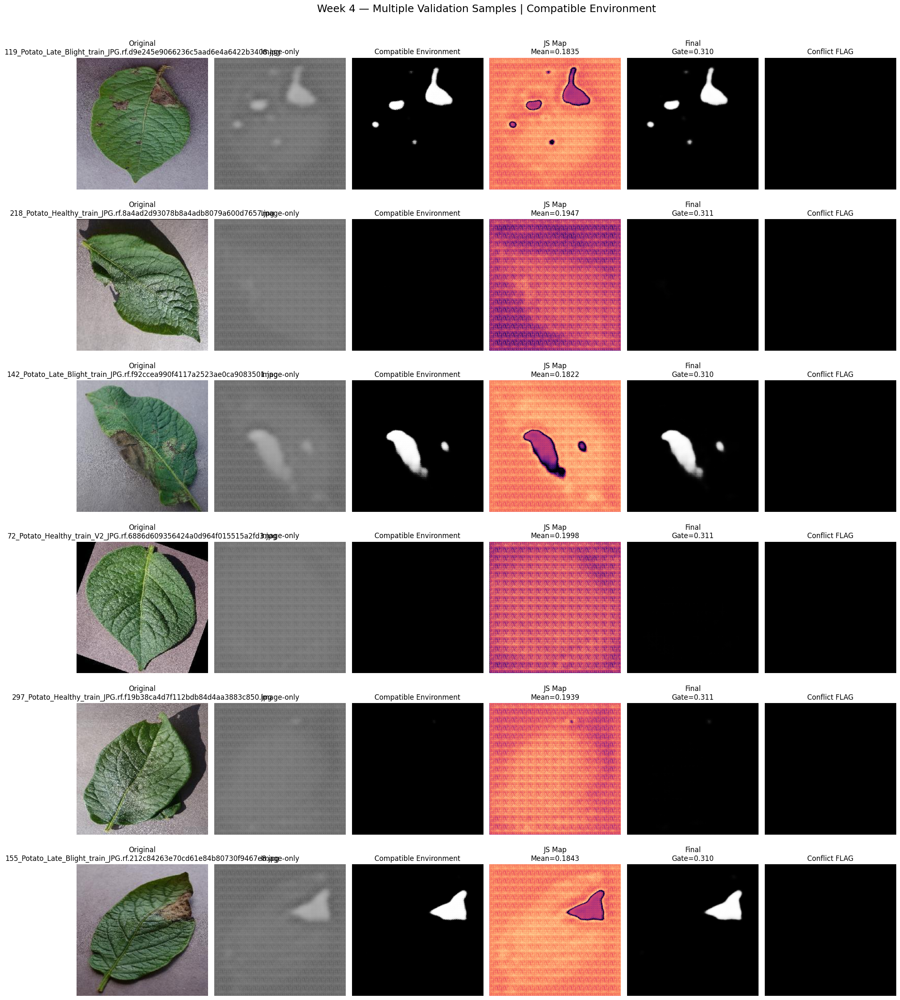

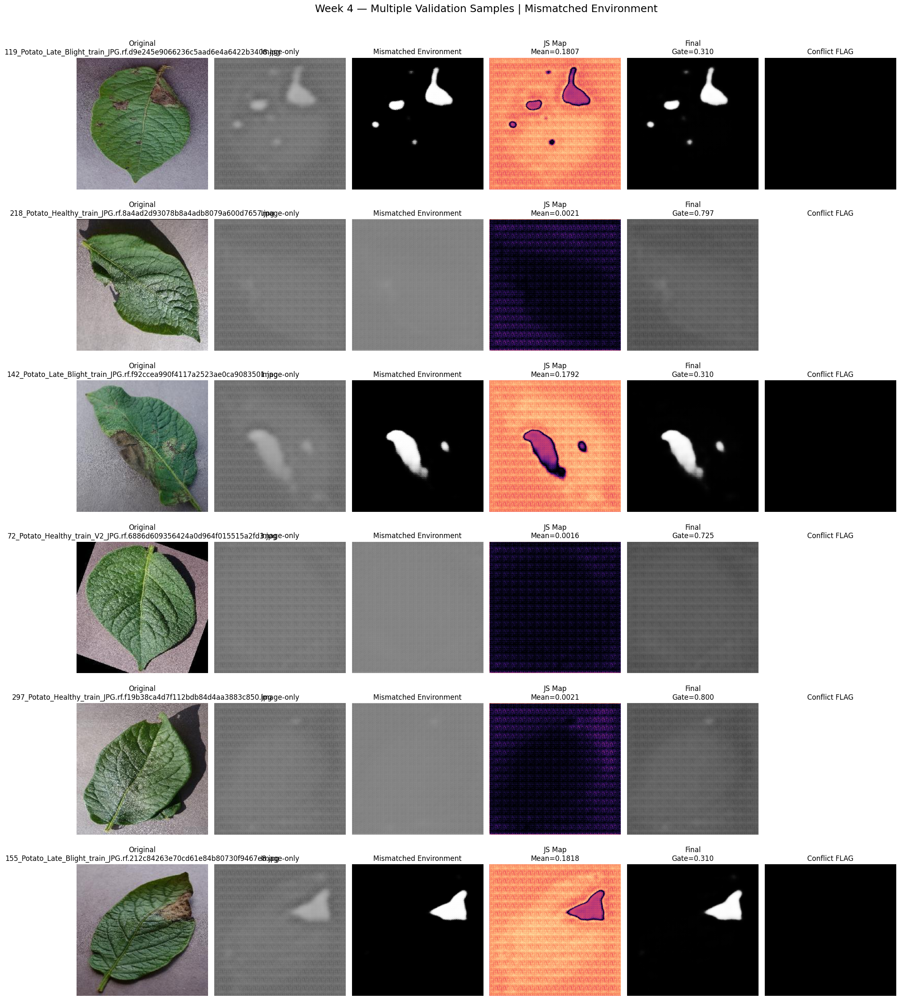


VISUALIZATION SUMMARY

[1] Validation index: 6
Image: 119_Potato_Late_Blight_train_JPG.rf.d9e245e9066236c5aad6e4a6422b3408.jpg
Mismatched environment from: 309_Potato_Healthy_train_JPG.rf.45e297e1c10064cc224be1e06fc088b8.jpg
Compatible JS: 0.183503
Mismatched JS: 0.180666
Compatible gate: 0.30957
Mismatched gate: 0.30957
Compatible conflict: False
Mismatched conflict: False

[2] Validation index: 34
Image: 218_Potato_Healthy_train_JPG.rf.8a4ad2d93078b8a4adb8079a600d7657.jpg
Mismatched environment from: 197_Potato_Late_Blight_train_JPG.rf.3fe7583ff6a7720bbb4d41a64bd590e5.jpg
Compatible JS: 0.194725
Mismatched JS: 0.002091
Compatible gate: 0.310547
Mismatched gate: 0.796875
Compatible conflict: False
Mismatched conflict: True

[3] Validation index: 11
Image: 142_Potato_Late_Blight_train_JPG.rf.f92ccea990f4117a2523ae0ca9083501.jpg
Mismatched environment from: 309_Potato_Healthy_train_JPG.rf.45e297e1c10064cc224be1e06fc088b8.jpg
Compatible JS: 0.182181
Mismatched JS: 0.179178
Compatible ga

In [5]:
# =====================================================================
# WEEK 4 — VISUALIZE MULTIPLE VALIDATION IMAGES AT ONCE
# Shows for each sample:
#   Original
#   Image-only prediction
#   Environment-conditioned prediction
#   JS disagreement map
#   Final prediction
#   Conflict flag
#
# Compatible + intentionally mismatched environment are both shown.
# =====================================================================

import os
import random
import numpy as np
import matplotlib.pyplot as plt
import torch

# -------------------------------------------------------------
# SETTINGS
# -------------------------------------------------------------

# Number of images to visualize
NUM_IMAGES = 6

# Set this if you want specific validation indices.
# Example:
# CUSTOM_INDICES = [0, 5, 12, 25, 50, 80]
#
# Use None for random selection.
CUSTOM_INDICES = None

# Random seed for reproducible random selection
VIS_SEED = 123

# Save directory
VIS_DIR = os.path.join(
    OUTPUT_DIR,
    "multi_image_visualizations"
)

os.makedirs(
    VIS_DIR,
    exist_ok=True
)


# -------------------------------------------------------------
# SELECT INDICES
# -------------------------------------------------------------

if CUSTOM_INDICES is not None:

    indices = CUSTOM_INDICES

else:

    rng = random.Random(
        VIS_SEED
    )

    total_samples = len(
        valid_ds
    )

    NUM_IMAGES = min(
        NUM_IMAGES,
        total_samples
    )

    indices = rng.sample(
        range(total_samples),
        NUM_IMAGES
    )


print("=" * 80)
print("SELECTED VALIDATION IMAGES")
print("=" * 80)

print(
    "Indices:",
    indices
)


# -------------------------------------------------------------
# HELPER: RUN ONE SAMPLE
# -------------------------------------------------------------

@torch.no_grad()
def get_visual_outputs(
    model,
    dataset,
    index
):

    model.eval()

    sample = dataset[
        index
    ]

    image = sample[
        "image"
    ].unsqueeze(
        0
    ).to(
        DEVICE
    )

    env_c = sample[
        "environment_compatible"
    ].unsqueeze(
        0
    ).to(
        DEVICE
    )

    env_m = sample[
        "environment_mismatch"
    ].unsqueeze(
        0
    ).to(
        DEVICE
    )

    # ---------------------------------------------------------
    # Forward
    # ---------------------------------------------------------

    with torch.autocast(
        device_type="cuda",
        dtype=torch.float16,
        enabled=AMP
    ):

        z = model.encode_image(
            image
        )

        image_feat = (
            model.image_features(
                z
            )
        )

        # Compatible environment
        out_c = model.predict_from_features(
            z,
            image_feat,
            env_c
        )

        # Mismatched environment
        out_m = model.predict_from_features(
            z,
            image_feat,
            env_m
        )

    # ---------------------------------------------------------
    # Convert image back to display format
    # ---------------------------------------------------------

    display = (
        image[0]
        .detach()
        .cpu()
        .permute(
            1,
            2,
            0
        )
        .numpy()
    )

    mean = np.array(
        [
            0.485,
            0.456,
            0.406
        ]
    )

    std = np.array(
        [
            0.229,
            0.224,
            0.225
        ]
    )

    display = (
        display * std + mean
    )

    display = np.clip(
        display,
        0,
        1
    )

    # ---------------------------------------------------------
    # Image-only prediction
    # ---------------------------------------------------------

    image_pred = torch.sigmoid(
        out_c[
            "image_logits"
        ].float()
    )[0, 0].cpu().numpy()

    # ---------------------------------------------------------
    # Compatible environment prediction
    # ---------------------------------------------------------

    env_pred_c = torch.sigmoid(
        out_c[
            "environment_logits"
        ].float()
    )[0, 0].cpu().numpy()

    # ---------------------------------------------------------
    # Mismatched environment prediction
    # ---------------------------------------------------------

    env_pred_m = torch.sigmoid(
        out_m[
            "environment_logits"
        ].float()
    )[0, 0].cpu().numpy()

    # ---------------------------------------------------------
    # JS disagreement maps
    # ---------------------------------------------------------

    js_c = out_c[
        "js_map"
    ][0, 0].cpu().numpy()

    js_m = out_m[
        "js_map"
    ][0, 0].cpu().numpy()

    # ---------------------------------------------------------
    # Gate values
    # ---------------------------------------------------------

    gate_c = float(
        out_c[
            "learned_gate"
        ].item()
    )

    gate_m = float(
        out_m[
            "learned_gate"
        ].item()
    )

    # ---------------------------------------------------------
    # Final compatible prediction
    #
    # Low conflict  -> fused
    # High conflict -> image-only
    # ---------------------------------------------------------

    gate_c_tensor = torch.tensor(
        gate_c,
        dtype=torch.float32,
        device=DEVICE
    ).view(
        1,
        1,
        1,
        1
    )

    final_c_logits = (
        (
            1.0
            -
            gate_c_tensor
        )
        *
        out_c[
            "fused_logits"
        ].float()
        +
        gate_c_tensor
        *
        out_c[
            "image_logits"
        ].float()
    )

    final_c = torch.sigmoid(
        final_c_logits
    )[0, 0].cpu().numpy()

    # ---------------------------------------------------------
    # Final mismatched prediction
    # ---------------------------------------------------------

    gate_m_tensor = torch.tensor(
        gate_m,
        dtype=torch.float32,
        device=DEVICE
    ).view(
        1,
        1,
        1,
        1
    )

    final_m_logits = (
        (
            1.0
            -
            gate_m_tensor
        )
        *
        out_m[
            "fused_logits"
        ].float()
        +
        gate_m_tensor
        *
        out_m[
            "image_logits"
        ].float()
    )

    final_m = torch.sigmoid(
        final_m_logits
    )[0, 0].cpu().numpy()

    # ---------------------------------------------------------
    # Conflict flags
    # ---------------------------------------------------------

    conflict_c = gate_c >= 0.5
    conflict_m = gate_m >= 0.5

    return {
        "sample": sample,
        "display": display,

        "image_pred": image_pred,

        "env_pred_c": env_pred_c,
        "env_pred_m": env_pred_m,

        "js_c": js_c,
        "js_m": js_m,

        "final_c": final_c,
        "final_m": final_m,

        "gate_c": gate_c,
        "gate_m": gate_m,

        "conflict_c": conflict_c,
        "conflict_m": conflict_m
    }


# -------------------------------------------------------------
# GENERATE ALL VISUAL OUTPUTS
# -------------------------------------------------------------

results = []

for index in indices:

    print(
        f"Processing validation index {index}..."
    )

    result = get_visual_outputs(
        model,
        valid_ds,
        index
    )

    results.append(
        result
    )


# -------------------------------------------------------------
# FIGURE 1:
# Compatible environments
#
# Each row = one image
# Columns:
# Original | Image-only | Env-conditioned |
# JS map | Final | Conflict flag
# -------------------------------------------------------------

fig, axes = plt.subplots(
    len(results),
    6,
    figsize=(
        20,
        4 * len(results)
    )
)

# Handle single-image case
if len(results) == 1:
    axes = np.expand_dims(
        axes,
        axis=0
    )


for row_idx, result in enumerate(
    results
):

    display = result[
        "display"
    ]

    image_pred = result[
        "image_pred"
    ]

    env_pred_c = result[
        "env_pred_c"
    ]

    js_c = result[
        "js_c"
    ]

    final_c = result[
        "final_c"
    ]

    gate_c = result[
        "gate_c"
    ]

    conflict_c = result[
        "conflict_c"
    ]

    filename = result[
        "sample"
    ]["filename"]

    # ---------------------------------------------------------
    # Column 1 — Original
    # ---------------------------------------------------------

    axes[
        row_idx,
        0
    ].imshow(
        display
    )

    axes[
        row_idx,
        0
    ].set_title(
        f"Original\n{filename}"
    )

    # ---------------------------------------------------------
    # Column 2 — Image-only
    # ---------------------------------------------------------

    axes[
        row_idx,
        1
    ].imshow(
        image_pred,
        cmap="gray",
        vmin=0,
        vmax=1
    )

    axes[
        row_idx,
        1
    ].set_title(
        "Image-only"
    )

    # ---------------------------------------------------------
    # Column 3 — Environment-conditioned
    # ---------------------------------------------------------

    axes[
        row_idx,
        2
    ].imshow(
        env_pred_c,
        cmap="gray",
        vmin=0,
        vmax=1
    )

    axes[
        row_idx,
        2
    ].set_title(
        "Compatible Environment"
    )

    # ---------------------------------------------------------
    # Column 4 — JS disagreement
    # ---------------------------------------------------------

    im = axes[
        row_idx,
        3
    ].imshow(
        js_c,
        cmap="magma"
    )

    axes[
        row_idx,
        3
    ].set_title(
        f"JS Map\nMean={js_c.mean():.4f}"
    )

    # ---------------------------------------------------------
    # Column 5 — Final
    # ---------------------------------------------------------

    axes[
        row_idx,
        4
    ].imshow(
        final_c,
        cmap="gray",
        vmin=0,
        vmax=1
    )

    axes[
        row_idx,
        4
    ].set_title(
        f"Final\nGate={gate_c:.3f}"
    )

    # ---------------------------------------------------------
    # Column 6 — Conflict flag
    # ---------------------------------------------------------

    axes[
        row_idx,
        5
    ].imshow(
        np.ones_like(
            js_c
        )
        *
        conflict_c,
        cmap="gray",
        vmin=0,
        vmax=1
    )

    axes[
        row_idx,
        5
    ].set_title(
        "Conflict FLAG"
    )

    for col in range(6):

        axes[
            row_idx,
            col
        ].axis("off")


fig.suptitle(
    "Week 4 — Multiple Validation Samples | Compatible Environment",
    fontsize=18,
    y=1.01
)

plt.tight_layout()

compatible_path = os.path.join(
    VIS_DIR,
    "multiple_validation_compatible.png"
)

plt.savefig(
    compatible_path,
    dpi=180,
    bbox_inches="tight"
)

plt.show()


# -------------------------------------------------------------
# FIGURE 2:
# INTENTIONALLY MISMATCHED ENVIRONMENT
#
# Same images, different environment sequence
# -------------------------------------------------------------

fig, axes = plt.subplots(
    len(results),
    6,
    figsize=(
        20,
        4 * len(results)
    )
)

if len(results) == 1:
    axes = np.expand_dims(
        axes,
        axis=0
    )


for row_idx, result in enumerate(
    results
):

    display = result[
        "display"
    ]

    image_pred = result[
        "image_pred"
    ]

    env_pred_m = result[
        "env_pred_m"
    ]

    js_m = result[
        "js_m"
    ]

    final_m = result[
        "final_m"
    ]

    gate_m = result[
        "gate_m"
    ]

    conflict_m = result[
        "conflict_m"
    ]

    filename = result[
        "sample"
    ]["filename"]

    mismatch_filename = result[
        "sample"
    ]["mismatch_filename"]

    # ---------------------------------------------------------
    # Original
    # ---------------------------------------------------------

    axes[
        row_idx,
        0
    ].imshow(
        display
    )

    axes[
        row_idx,
        0
    ].set_title(
        f"Original\n{filename}"
    )

    # ---------------------------------------------------------
    # Image-only
    # ---------------------------------------------------------

    axes[
        row_idx,
        1
    ].imshow(
        image_pred,
        cmap="gray",
        vmin=0,
        vmax=1
    )

    axes[
        row_idx,
        1
    ].set_title(
        "Image-only"
    )

    # ---------------------------------------------------------
    # Mismatched environment prediction
    # ---------------------------------------------------------

    axes[
        row_idx,
        2
    ].imshow(
        env_pred_m,
        cmap="gray",
        vmin=0,
        vmax=1
    )

    axes[
        row_idx,
        2
    ].set_title(
        "Mismatched Environment"
    )

    # ---------------------------------------------------------
    # JS disagreement
    # ---------------------------------------------------------

    axes[
        row_idx,
        3
    ].imshow(
        js_m,
        cmap="magma"
    )

    axes[
        row_idx,
        3
    ].set_title(
        f"JS Map\nMean={js_m.mean():.4f}"
    )

    # ---------------------------------------------------------
    # Final
    # ---------------------------------------------------------

    axes[
        row_idx,
        4
    ].imshow(
        final_m,
        cmap="gray",
        vmin=0,
        vmax=1
    )

    axes[
        row_idx,
        4
    ].set_title(
        f"Final\nGate={gate_m:.3f}"
    )

    # ---------------------------------------------------------
    # Conflict flag
    # ---------------------------------------------------------

    axes[
        row_idx,
        5
    ].imshow(
        np.ones_like(
            js_m
        )
        *
        conflict_m,
        cmap="gray",
        vmin=0,
        vmax=1
    )

    axes[
        row_idx,
        5
    ].set_title(
        "Conflict FLAG"
    )

    for col in range(6):

        axes[
            row_idx,
            col
        ].axis("off")


fig.suptitle(
    "Week 4 — Multiple Validation Samples | Mismatched Environment",
    fontsize=18,
    y=1.01
)

plt.tight_layout()

mismatch_path = os.path.join(
    VIS_DIR,
    "multiple_validation_mismatched.png"
)

plt.savefig(
    mismatch_path,
    dpi=180,
    bbox_inches="tight"
)

plt.show()


# -------------------------------------------------------------
# NUMERIC SUMMARY
# -------------------------------------------------------------

print("\n" + "=" * 80)
print("VISUALIZATION SUMMARY")
print("=" * 80)

for i, result in enumerate(
    results
):

    sample = result[
        "sample"
    ]

    print(
        f"\n[{i+1}] Validation index: {indices[i]}"
    )

    print(
        "Image:",
        sample["filename"]
    )

    print(
        "Mismatched environment from:",
        sample["mismatch_filename"]
    )

    print(
        "Compatible JS:",
        round(
            result["js_c"].mean(),
            6
        )
    )

    print(
        "Mismatched JS:",
        round(
            result["js_m"].mean(),
            6
        )
    )

    print(
        "Compatible gate:",
        round(
            result["gate_c"],
            6
        )
    )

    print(
        "Mismatched gate:",
        round(
            result["gate_m"],
            6
        )
    )

    print(
        "Compatible conflict:",
        result["conflict_c"]
    )

    print(
        "Mismatched conflict:",
        result["conflict_m"]
    )


print("\nSaved files:")
print(
    compatible_path
)

print(
    mismatch_path
)